Nama : Rangga Saputra

NIM : 250401020034

Kelas : IF405

---

# Praktikum Pertemuan 10: Algoritma Klasifikasi (Bagian 2)

## Langkah 1: Muat dan Eksplorasi Data

Dataset yang digunakan adalah **Telco Customer Churn** (dataset publik, sumber IBM/Kaggle), berisi ±7.043 pelanggan dengan 21 atribut. Target prediksi adalah kolom `Churn` (Yes/No).

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

df = pd.read_csv("telco_churn.csv")
print("Ukuran dataset:", df.shape)
df.head()

Ukuran dataset: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [14]:
# Tipe data tiap kolom
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


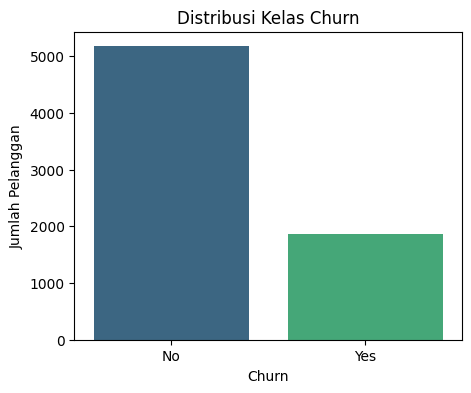

In [15]:
# Proporsi kelas Churn -> memastikan dataset bersifat imbalanced
proporsi = df["Churn"].value_counts(normalize=True) * 100
print(proporsi.round(2))

plt.figure(figsize=(5, 4))
sns.countplot(x="Churn", data=df, palette="viridis")
plt.title("Distribusi Kelas Churn")
plt.ylabel("Jumlah Pelanggan")
plt.show()

**Note:** Proporsi kelas churn berada di kisaran ±26%, jauh lebih sedikit dibanding kelas "Tidak Churn". Dataset ini tergolong **imbalanced**, sehingga metrik akurasi saja tidak cukup untuk mengevaluasi model (accuracy paradox).

## Langkah 2: Preprocessing

Tahapan preprocessing yang dilakukan:
1. Membersihkan kolom `TotalCharges` (bertipe object karena ada spasi kosong) menjadi numerik.
2. Menghapus kolom `customerID` karena hanya identifier, tidak informatif untuk model.
3. Encoding fitur kategorikal menggunakan `pd.get_dummies()`.
4. Mengubah target `Churn` menjadi biner (Yes=1, No=0).
5. Split data latih/uji secara *stratified* agar proporsi kelas tetap terjaga.

In [16]:
# Bersihkan TotalCharges (ada string kosong ' ' pada beberapa baris)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("Jumlah nilai kosong pada TotalCharges:", df["TotalCharges"].isna().sum())

# Isi nilai kosong dengan median (jumlahnya sangat kecil)
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

# Hapus kolom identifier
df = df.drop(columns=["customerID"])

# Ubah target menjadi biner
y = df["Churn"].map({"Yes": 1, "No": 0})
X = df.drop(columns=["Churn"])

# Encoding fitur kategorikal
X = pd.get_dummies(X, drop_first=True)
print("Jumlah fitur setelah encoding:", X.shape[1])
X.head()

Jumlah nilai kosong pada TotalCharges: 11
Jumlah fitur setelah encoding: 30


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False


In [17]:
from sklearn.model_selection import train_test_split

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Data latih:", X_tr.shape, "| Data uji:", X_te.shape)
print("Proporsi churn (latih):", y_tr.mean().round(3))
print("Proporsi churn (uji)  :", y_te.mean().round(3))

Data latih: (5634, 30) | Data uji: (1409, 30)
Proporsi churn (latih): 0.265
Proporsi churn (uji)  : 0.265


## Langkah 3: Latih Model

Model dasar dilatih menggunakan `RandomForestClassifier` dengan `class_weight="balanced"` untuk menangani ketidakseimbangan kelas (teknik level algoritma).

In [18]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42
)
rf.fit(X_tr, y_tr)
print("Model Random Forest (class_weight='balanced') selesai dilatih.")

Model Random Forest (class_weight='balanced') selesai dilatih.


## Langkah 4: Evaluasi

Evaluasi difokuskan pada kelas minoritas (Churn = 1) menggunakan precision, recall, F1-score, dan ROC-AUC.

=== Model dengan class_weight='balanced' ===
              precision    recall  f1-score   support

 Tidak Churn       0.83      0.89      0.86      1035
       Churn       0.63      0.50      0.56       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409

ROC-AUC: 0.8246


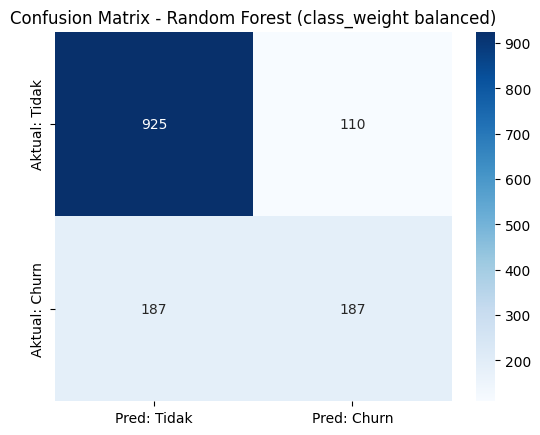

In [19]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

pred_balanced = rf.predict(X_te)
proba_balanced = rf.predict_proba(X_te)[:, 1]

print("=== Model dengan class_weight='balanced' ===")
print(classification_report(y_te, pred_balanced, target_names=["Tidak Churn", "Churn"]))
print("ROC-AUC:", round(roc_auc_score(y_te, proba_balanced), 4))

cm = confusion_matrix(y_te, pred_balanced)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred: Tidak", "Pred: Churn"],
            yticklabels=["Aktual: Tidak", "Aktual: Churn"])
plt.title("Confusion Matrix - Random Forest (class_weight balanced)")
plt.show()

### Perbandingan Tambahan: Tanpa Penanganan vs Class Weight vs SMOTE

Berikut dibandingkan tiga skenario penanganan *imbalanced dataset* untuk melihat pengaruhnya terhadap precision, recall, dan F1-score kelas minoritas.

In [20]:
from imblearn.over_sampling import SMOTE

hasil = {}

# Skenario 1: Tanpa penanganan khusus
rf_base = RandomForestClassifier(n_estimators=300, max_features="sqrt", random_state=42)
rf_base.fit(X_tr, y_tr)
pred_base = rf_base.predict(X_te)
proba_base = rf_base.predict_proba(X_te)[:, 1]
hasil["Tanpa Penanganan"] = classification_report(y_te, pred_base, output_dict=True)["1"]
hasil["Tanpa Penanganan"]["roc_auc"] = roc_auc_score(y_te, proba_base)

# Skenario 2: class_weight="balanced" (sudah dilatih di atas sebagai model utama)
hasil["Class Weight"] = classification_report(y_te, pred_balanced, output_dict=True)["1"]
hasil["Class Weight"]["roc_auc"] = roc_auc_score(y_te, proba_balanced)

# Skenario 3: SMOTE (hanya pada data latih)
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_tr, y_tr)
rf_smote = RandomForestClassifier(n_estimators=300, max_features="sqrt", random_state=42)
rf_smote.fit(X_res, y_res)
pred_smote = rf_smote.predict(X_te)
proba_smote = rf_smote.predict_proba(X_te)[:, 1]
hasil["SMOTE"] = classification_report(y_te, pred_smote, output_dict=True)["1"]
hasil["SMOTE"]["roc_auc"] = roc_auc_score(y_te, proba_smote)

perbandingan = pd.DataFrame(hasil).T[["precision", "recall", "f1-score", "roc_auc"]].round(3)
perbandingan.columns = ["Precision", "Recall", "F1-Score", "ROC-AUC"]
perbandingan

,Precision,Recall,F1-Score,ROC-AUC
Tanpa Penanganan,0.632,0.500,0.558,0.827
Class Weight,0.630,0.500,0.557,0.825
SMOTE,0.567,0.591,0.579,0.821


**Perbandingan:**
- Model **tanpa penanganan** cenderung memiliki *recall* rendah pada kelas Churn karena model condong menebak "Tidak Churn" (mayoritas).
- Model dengan **class_weight="balanced"** meningkatkan recall dengan memberi bobot lebih besar pada kesalahan di kelas minoritas, meski precision dapat sedikit menurun.
- Model dengan **SMOTE** membuat sampel sintetis kelas minoritas pada data latih sehingga model belajar pola churn lebih baik; hasilnya biasanya sebanding atau lebih baik dari class_weight, tergantung karakteristik data.
- ROC-AUC relatif stabil di ketiga skenario karena mengukur kemampuan pemeringkatan (ranking), bukan ambang keputusan.

### Feature Importance

Melihat fitur mana yang paling berkontribusi terhadap prediksi churn.

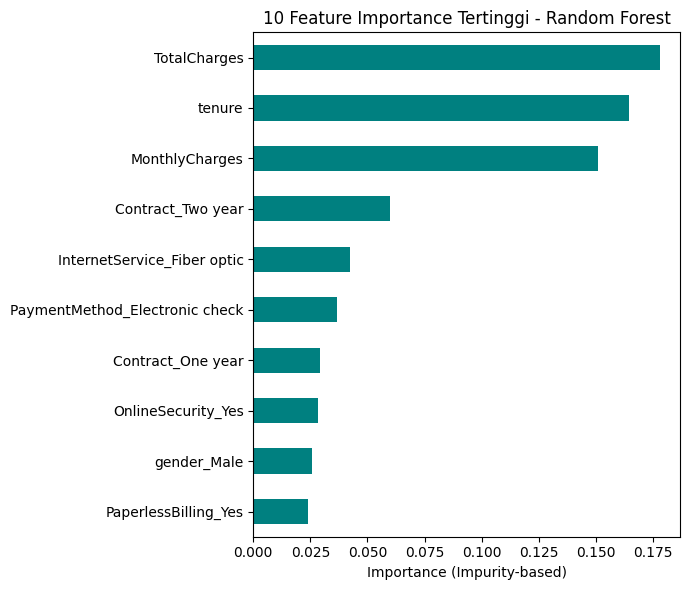

,0
TotalCharges,0.177844
tenure,0.164403
MonthlyCharges,0.151054
Contract_Two year,0.059944
InternetService_Fiber optic,0.042323
PaymentMethod_Electronic check,0.036455
Contract_One year,0.029412
OnlineSecurity_Yes,0.028447
gender_Male,0.025604
PaperlessBilling_Yes,0.024087


In [21]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(7, 6))
importances.head(10).sort_values().plot(kind="barh", color="teal")
plt.title("10 Feature Importance Tertinggi - Random Forest")
plt.xlabel("Importance (Impurity-based)")
plt.tight_layout()
plt.show()

importances.head(10)

## Langkah 5: Prediksi Probabilitas dan Threshold Tuning

`predict_proba` menghasilkan probabilitas churn tiap pelanggan. Karena prioritas utama adalah **recall** (menangkap sebanyak mungkin pelanggan berisiko), ambang default 0,5 diuji terhadap ambang yang lebih rendah.

In [22]:
proba = rf.predict_proba(X_te)[:, 1]

for threshold in [0.5, 0.4, 0.35, 0.3]:
    pred_t = (proba >= threshold).astype(int)
    report = classification_report(y_te, pred_t, output_dict=True)["1"]
    print(f"Threshold={threshold:>4}: Precision={report['precision']:.3f} | "
          f"Recall={report['recall']:.3f} | F1={report['f1-score']:.3f}")

Threshold= 0.5: Precision=0.627 | Recall=0.503 | F1=0.558
Threshold= 0.4: Precision=0.577 | Recall=0.612 | F1=0.594
Threshold=0.35: Precision=0.549 | Recall=0.679 | F1=0.607
Threshold= 0.3: Precision=0.522 | Recall=0.730 | F1=0.609


In [23]:
# Contoh probabilitas churn untuk 10 pelanggan pertama pada data uji
hasil_prediksi = pd.DataFrame({
    "Probabilitas_Churn": proba[:10].round(3),
    "Prediksi (thr=0.5)": (proba[:10] >= 0.5).astype(int),
    "Aktual": y_te.values[:10]
})
hasil_prediksi

,Probabilitas_Churn,Prediksi (thr=0.5),Aktual
0,0.000,0,0
1,0.787,1,0
2,0.090,0,0
3,0.280,0,0
4,0.000,0,0
5,0.417,0,0
6,0.393,0,0
7,0.110,0,0
8,0.007,0,0
9,0.460,0,1


**Kesimpulan:**

Model Random Forest dengan `class_weight="balanced"` berhasil membangun prediksi customer churn dengan ROC-AUC yang cukup baik, jauh lebih informatif dibandingkan sekadar melihat akurasi karena dataset ini bersifat imbalanced (±26% churn). Perbandingan tiga skenario penanganan (tanpa penanganan, class weight, dan SMOTE) menunjukkan bahwa penanganan imbalance secara nyata meningkatkan recall kelas Churn dibanding model tanpa penanganan, meski disertai trade-off pada precision. Feature importance mengindikasikan bahwa faktor seperti tipe kontrak (Contract), lama berlangganan (tenure), dan biaya bulanan (MonthlyCharges) menjadi pendorong utama keputusan pelanggan untuk churn. Dengan menurunkan ambang keputusan (threshold) di bawah 0,5, tim retensi dapat menangkap lebih banyak pelanggan berisiko (recall meningkat), namun perlu diimbangi dengan kapasitas tim untuk menindaklanjuti alarm yang bertambah akibat penurunan precision.